In [77]:
import warnings
warnings.filterwarnings('ignore')

from functions import *
from sklearn.linear_model import LinearRegression
from matplotlib import pyplot as plt
import seaborn as sns


palette = 'viridis'
font = {'color':  'black', 'weight': 'normal','size': 14}
font_cb = { 'color':  'black', 'weight': 'normal','size': 12}
labelsize=12

data = pd.read_csv('results/data.csv', index_col='Cluster')
df = pd.read_csv('results/results.csv', index_col='Cluster')

# Distance and $A_V$ effects on binary fraction

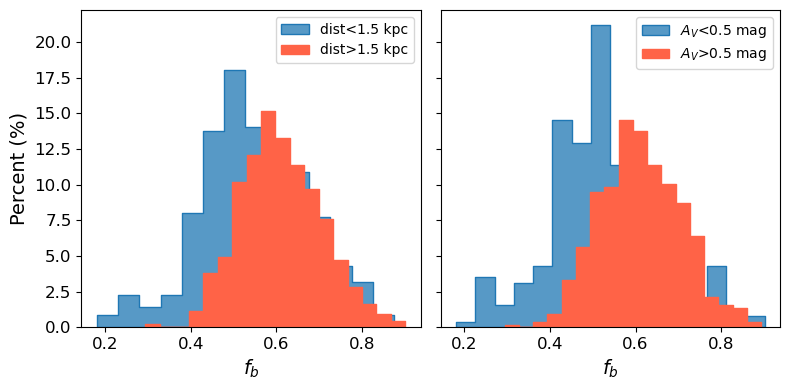

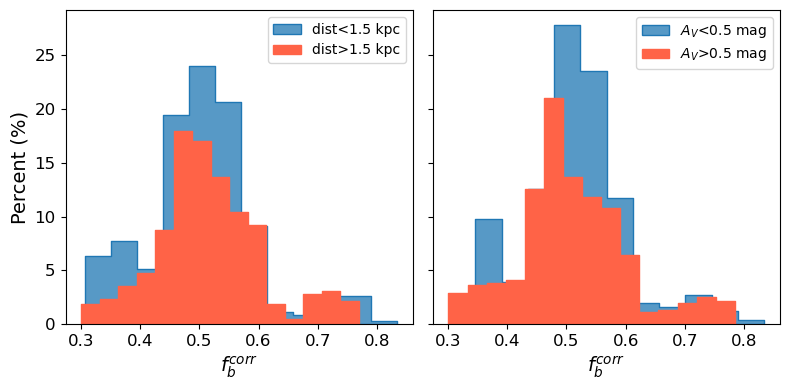

In [78]:
fig, axs = plt.subplots(1,2, figsize=(8,4), sharey=True)

stat = 'percent'
sns.histplot(data=df[df['dist']<1.5], x='bin_frac', element='step', stat= stat, ax =axs[0], label = 'dist<1.5 kpc',)
sns.histplot(data=df[df['dist']>1.5], x='bin_frac', element='step', stat= stat, ax = axs[0], label = 'dist>1.5 kpc', color = 'tomato',
            alpha=1)

sns.histplot(data=df[df['Av']<1], x='bin_frac', element='step', stat= stat, ax = axs[1], label = r'$A_V$<0.5 mag',)
sns.histplot(data=df[df['Av']>1], x='bin_frac', element='step', stat= stat, ax = axs[1], label = r'$A_V$>0.5 mag', color = 'tomato',
            alpha=1)


for ax in axs.flat:
    ax.legend()
    ax.set_xlabel(r'$f_b$', fontdict=font)
    ax.set_ylabel('Percent (%)', fontdict=font)
    ax.tick_params(labelsize=12)
    


plt.tight_layout()
#plt.savefig('Figures/systematic_bias.png',bbox_inches='tight', dpi=300)
plt.show()


fig, axs = plt.subplots(1,2, figsize=(8,4), sharey=True)


sns.histplot(data=df[df['dist']<1.5], x='bin_frac_corr', element='step', stat= stat, ax =axs[0], label = 'dist<1.5 kpc', bins=12)
sns.histplot(data=df[df['dist']>1.5], x='bin_frac_corr', element='step', stat= stat, ax = axs[0], label = 'dist>1.5 kpc', color = 'tomato', bins=15,
            alpha=1)

sns.histplot(data=df[df['Av']<1], x='bin_frac_corr', element='step', stat= stat, ax = axs[1], label = r'$A_V$<0.5 mag', bins=12)
sns.histplot(data=df[df['Av']>1], x='bin_frac_corr', element='step', stat= stat, ax = axs[1], label = r'$A_V$>0.5 mag', color = 'tomato', bins=15,
            alpha=1)


for ax in axs.flat:
    ax.legend()
    ax.set_xlabel(r'$f_b^{corr}$', fontdict=font)
    ax.set_ylabel('Percent (%)', fontdict=font)
    ax.tick_params(labelsize=12)
    


plt.tight_layout()
#plt.savefig('Figures/systematic_bias_corr.png',bbox_inches='tight', dpi=300)
plt.show()


## Define benchmark subsample

In [79]:
#Define benchmark subsample
Av_lim = 0.5
dist_lim = 1.5
mask =  (df['Av']< Av_lim) & (df['dist']< dist_lim)
benchmark  = df[mask].copy()

In [81]:
benchmark

,RA_ICRS,DE_ICRS,dist,e_dist,age,e_age,FeH,e_FeH,Av,e_Av,...,er_bin_frac,bin_frac_05,bin_frac_05_corr,er_bin_frac_05,rh,e_rh,t_relax,e_t_relax,tau,e_tau
Cluster,,,,,,,,,,,,,,,,,,,,,
ASCC_113,318.0091,38.6407,0.558,0.000,8.493,0.088,0.001,0.025,0.245,0.049,...,0.030216,0.219697,0.414296,0.025482,4.821043,0.357293,79.205205,11.804849,3.928677,0.988210
ASCC_16,81.2316,1.6235,0.342,0.001,7.301,0.072,0.180,0.019,0.038,0.053,...,0.068288,0.322245,0.204084,0.049894,2.804166,0.248904,55.316959,9.203557,0.361528,0.084914
ASCC_21,82.1709,3.4393,0.339,0.000,7.011,0.035,-0.118,0.040,0.283,0.065,...,0.024710,0.203704,0.395977,0.022375,3.163276,0.359424,48.573853,9.585147,0.211153,0.045008
ASCC_23,94.9038,46.6552,0.604,0.001,8.489,0.084,-0.069,0.046,0.376,0.044,...,0.038890,0.400000,0.367385,0.164483,2.902845,0.318295,35.048325,6.724461,8.796962,2.396610
ASCC_29,103.5560,-1.6495,0.988,0.011,8.129,0.085,-0.077,0.025,0.245,0.023,...,0.053978,0.192771,0.308130,0.043299,2.343311,0.330012,16.531601,3.852264,8.141138,2.477455
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
UPK_640,250.3211,-39.5645,0.175,0.001,7.386,0.039,0.145,0.046,0.321,0.064,...,0.022492,0.211765,0.236982,0.019818,2.230786,0.225440,35.904932,6.520370,0.677401,0.137235
UPK_654,277.2076,-34.4729,0.497,0.001,8.517,0.168,-0.048,0.058,0.458,0.137,...,0.052705,0.355556,0.236808,0.114933,2.575362,0.238262,27.973065,4.784803,11.756010,4.972375
UPK_82,298.2139,26.4639,0.504,0.018,8.119,0.133,-0.051,0.065,0.379,0.040,...,0.123939,0.493590,0.287500,0.093231,3.879685,0.407185,58.753870,10.928266,2.238533,0.802075


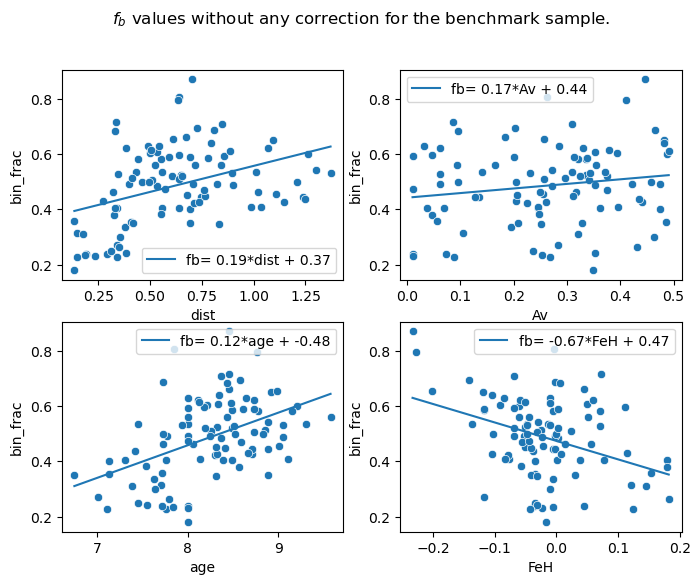

In [82]:
fig, axs = plt.subplots(2,2, figsize=(8,6))
i=0
j=0
y = 'bin_frac'
xs = ['dist', 'Av', 'age', 'FeH']
for x in xs:
    
    model = LinearRegression()
    model.fit(benchmark[[x]], benchmark[y])
    x_range = np.linspace(benchmark[x].min(), benchmark[x].max(), 200)
    y_pred = model.predict(x_range.reshape(-1,1)) 
    sns.scatterplot(data=benchmark, x =x, y=y, ax=axs[i,j],)
    sns.lineplot(x = x_range, y = y_pred, ax = axs[i,j],label=f'fb= {model.coef_[0]:.2f}*{x} + {model.intercept_:.2f}')
    
    j = j+1
    if j>1:
        j=0
        i = i+1

plt.suptitle(r'$f_b$ values without any correction for the benchmark sample.')
plt.show()

# Attempts to correct for the binary fraction

## 1. Correction by mean values of $f_b$ in the benchmark subsample

1. Calculate the mean of the binary fraction in the benchmark sample.

2. Define bins of 0.5 Av to correct the $f_b$ in the total sample.

3. For each bin of Av:

    - Calculate the mean of the $f_b$ of the total sample within the bin.

    - Calculate $\delta = \bar{f_b}(A_V) - \bar{f_b}^{bench}$

4. Correct the binary fraction values of each bin using $f_{b_{corrected}} = f_b - \delta$


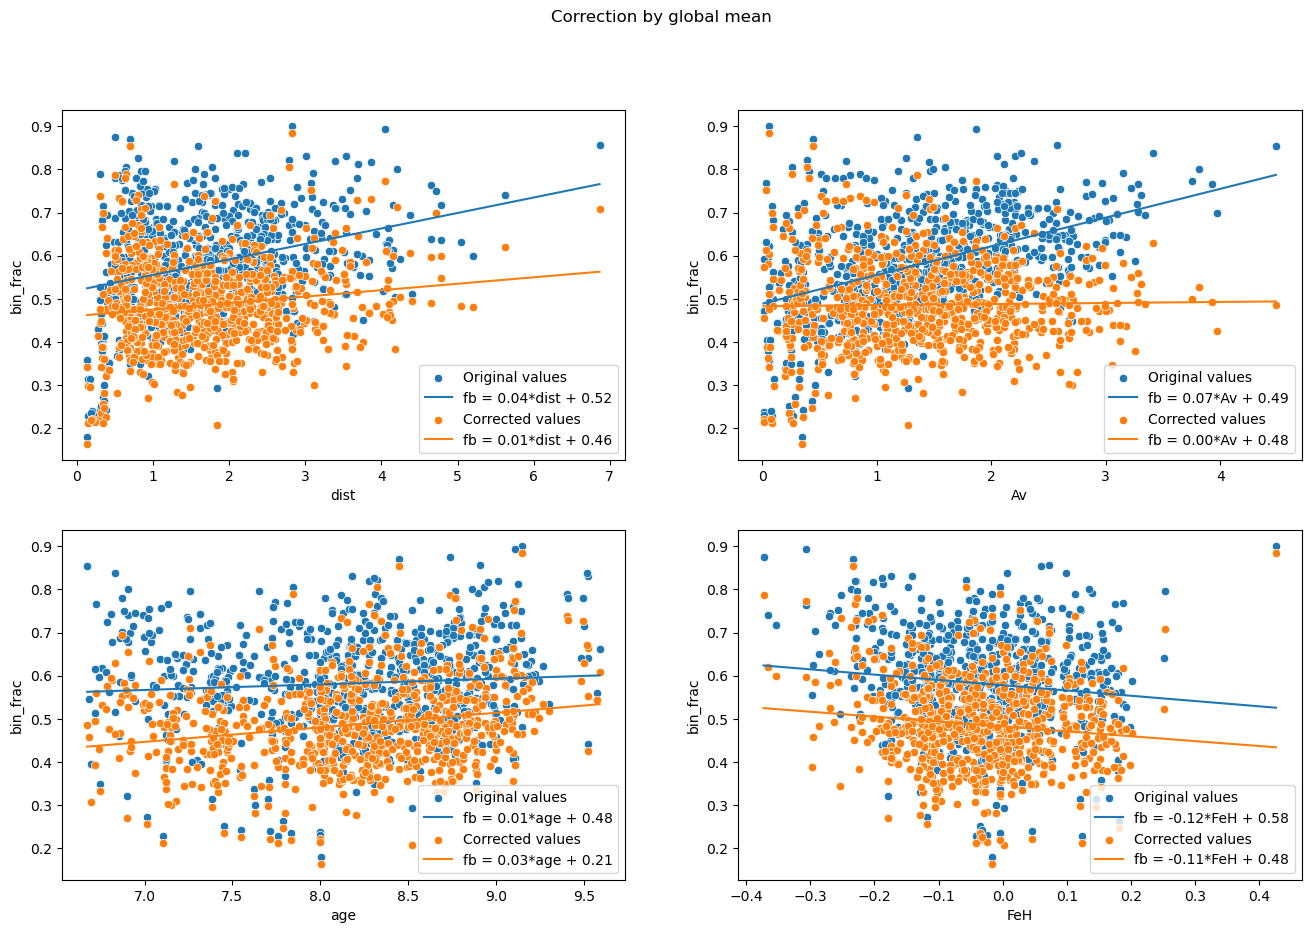

In [5]:
df_corr = df[['age', 'FeH', 'dist', 'Av', 'bin_frac', 'mass_total', 'n_members']].copy()
mean_bf_bench = benchmark['bin_frac'].mean()

bin_range = 0.5
Av = 0
while Av <= df['Av'].max():
    mask = (df['Av']>= Av) & (df['Av']< Av+bin_range)
    aux = df[mask]
    if len(aux) > 0:
        mean_bf_aux = aux['bin_frac'].mean()
        shift = mean_bf_aux - mean_bf_bench
        df_corr.loc[mask, 'corr_mean'] = aux['bin_frac'] - shift

    Av += bin_range


fig, axs = plt.subplots(2,2, figsize=(16,10))

y = 'bin_frac'
xs = ['dist', 'Av', 'age', 'FeH']
i=0
j=0
for x in xs:
    
    sns.scatterplot(data=df_corr, x =x, y=y, ax=axs[i,j],label='Original values')
    model = LinearRegression()
    model.fit(df_corr[[x]], df_corr[y])
    x_range = np.linspace(df_corr[x].min(), df_corr[x].max(), 200)
    y_pred = model.predict(x_range.reshape(-1,1)) 
    sns.lineplot(x = x_range, y = y_pred, ax = axs[i,j],label=f'fb = {model.coef_[0]:.2f}*{x} + {model.intercept_:.2f}')
    
    
    sns.scatterplot(data = df_corr, x = x, y= 'corr_mean', ax=axs[i,j],label='Corrected values')
    model = LinearRegression()
    model.fit(df_corr[[x]], df_corr['corr_mean'])
    x_range = np.linspace(df_corr[x].min(), df_corr[x].max(), 200)
    y_pred = model.predict(x_range.reshape(-1,1))
    
    sns.lineplot(x = x_range, y = y_pred, ax = axs[i,j], label=f'fb = {model.coef_[0]:.2f}*{x} + {model.intercept_:.2f}')
    

                
    
    
    j = j+1
    if j>1:
        j=0
        i = i+1
plt.suptitle('Correction by global mean')
plt.show()

## 2. Using Moving Average

$MM_i = \frac{1}{w}\sum_{_{k=i-w/2}}^{i+w/2} f_{b_k}$

w is the window size

The correction in the binary fraction was calculated as:

$f_{b_{corrected}} = f_b - (MM - \bar{f_b}^{bench})$

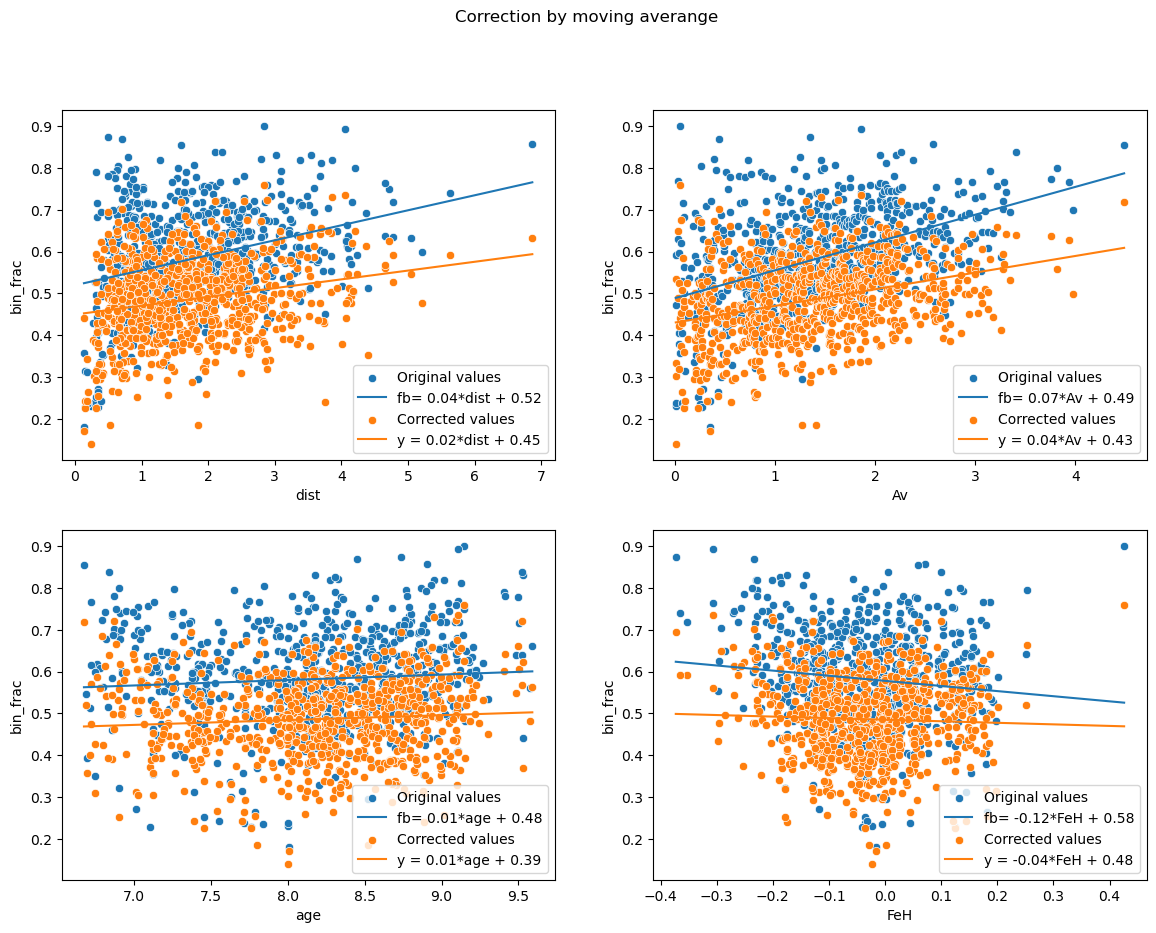

In [6]:
df_corr = df_corr.sort_values('Av').copy()

mean_bf_bench = benchmark['bin_frac'].mean()

window = 5 
mm = df['bin_frac'].rolling(window=window, center=True, min_periods=1).mean()

df_corr['corr_MA'] = df_corr['bin_frac'] - (mm - mean_bf_bench)

fig, axs = plt.subplots(2,2, figsize=(14,10))



i=0
j=0
for x in xs:
    
    model = LinearRegression()
    model.fit(df_corr[[x]], df_corr[y])
    x_range = np.linspace(df_corr[x].min(), df_corr[x].max(), 200)
    y_pred = model.predict(x_range.reshape(-1,1)) 
    sns.scatterplot(data=df_corr, x =x, y=y, ax=axs[i,j],label='Original values')
    sns.lineplot(x = x_range, y = y_pred, ax = axs[i,j],label=f'fb= {model.coef_[0]:.2f}*{x} + {model.intercept_:.2f}')
    
    model = LinearRegression()
    model.fit(df_corr[[x]], df_corr['corr_MA'])
    x_range = np.linspace(df_corr[x].min(), df_corr[x].max(), 200)
    y_pred = model.predict(x_range.reshape(-1,1))
    sns.scatterplot(data = df_corr, x = x, y= 'corr_MA', ax=axs[i,j],label='Corrected values')
    sns.lineplot(x = x_range, y = y_pred, ax = axs[i,j], label=f'y = {model.coef_[0]:.2f}*{x} + {model.intercept_:.2f}')
    
    j = j+1
    if j>1:
        j=0
        i = i+1

plt.suptitle('Correction by moving averange')
plt.show()

# 3. Correction by similarity

Assuming that the binary fraction should not vary significantly in clusters with the same properties but subject to different observational conditions, the correction of the $f_b$ values can be estimated as:

$f_b^\mathrm{corr} = \frac{\sum_{n=1}^{5}w_nf_{b,n}}{\sum_{n=1}^{5}w_n}$

with $w_n = 1/D_{i,j}$ and $D_{i,j}$ is the distance, in the parameters space, between the cluster analyzed and the cluster in benchmark subsample.

In [13]:
for cluster in df_corr.index:
    df_corr.loc[cluster, 'corr_similarity'] = corr_fb_by_similarity(df, 'bin_frac', cluster)

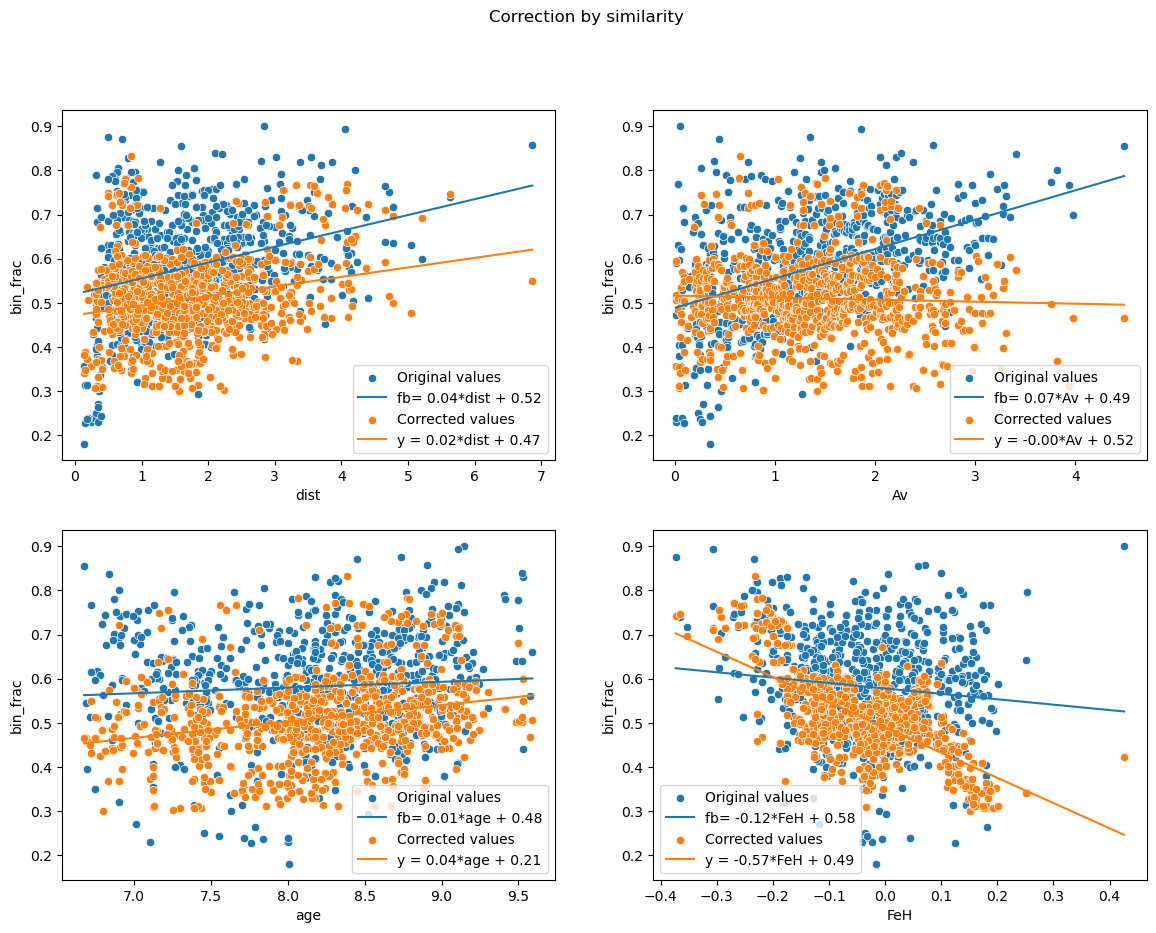

In [18]:
fig, axs = plt.subplots(2,2, figsize=(14,10))
i=0
j=0
for x in xs:
    
    model = LinearRegression()
    model.fit(df_corr[[x]], df_corr[y])
    x_range = np.linspace(df_corr[x].min(), df_corr[x].max(), 200)
    y_pred = model.predict(x_range.reshape(-1,1)) 
    sns.scatterplot(data=df_corr, x =x, y=y, ax=axs[i,j],label='Original values')
    sns.lineplot(x = x_range, y = y_pred, ax = axs[i,j],label=f'fb= {model.coef_[0]:.2f}*{x} + {model.intercept_:.2f}')
    
    model = LinearRegression()
    model.fit(df_corr[[x]], df_corr['corr_similarity'])
    x_range = np.linspace(df_corr[x].min(), df_corr[x].max(), 200)
    y_pred = model.predict(x_range.reshape(-1,1))
    sns.scatterplot(data = df_corr, x = x, y= 'corr_similarity', ax=axs[i,j],label='Corrected values')
    sns.lineplot(x = x_range, y = y_pred, ax = axs[i,j], label=f'y = {model.coef_[0]:.2f}*{x} + {model.intercept_:.2f}')
    
    j = j+1
    if j>1:
        j=0
        i = i+1

plt.suptitle('Correction by similarity')
plt.show()

# Comparing the corrections

In [83]:
vars_ = ['bin_frac', 'corr_mean', 'corr_MA', 'corr_similarity']
df_corr[vars_].describe().round(2)

,bin_frac,corr_mean,corr_MA,corr_similarity
count,772.00,772.00,772.00,772.00
mean,0.58,0.49,0.49,0.51
std,0.11,0.10,0.10,0.09
min,0.18,0.16,0.14,0.30
25%,0.51,0.42,0.43,0.46
50%,0.58,0.48,0.49,0.50
75%,0.66,0.55,0.55,0.56
max,0.90,0.88,0.76,0.83


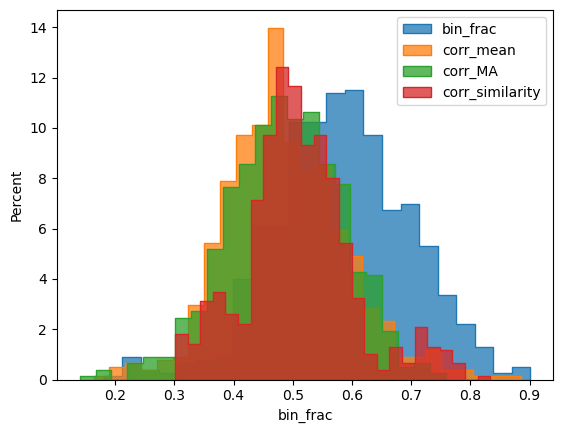

In [84]:
for var in vars_:
    sns.histplot(data = df_corr, x = var, stat = 'percent', element ='step', label = var)
plt.legend()
plt.show()

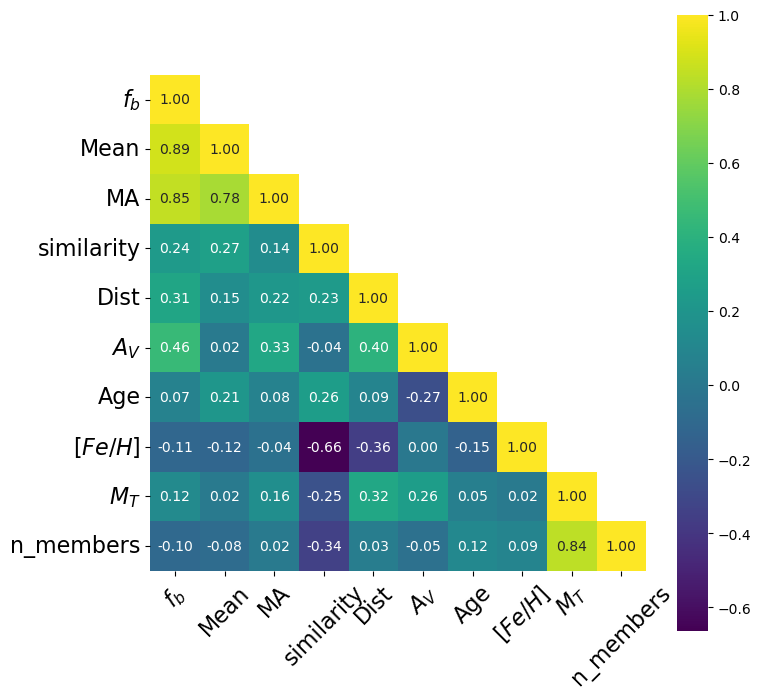

In [49]:
nome_vars = {
    'bin_frac': r'$f_b$',
    'corr_mean': 'Mean', 
    'corr_MA': 'MA',
    'corr_similarity': 'similarity',
    'dist': r'Dist',
    'Av': r'$A_V$',
    'age': r'Age',
    'FeH': r'[$Fe/H$]',
    'mass_total': r'$M_T$',
    'n_members' : 'n_members'
}

cols = list(nome_vars.keys())
corr = df_corr[cols].corr(method='pearson')
corr.rename(index=nome_vars, columns=nome_vars, inplace=True)

mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

fig = plt.figure(figsize=(8, 8))
cmap = palette 

ax = sns.heatmap(corr, mask=mask, annot=True, cmap=cmap, fmt=".2f", square=True, cbar=True,)

for label in ax.get_xticklabels():
    label.set_fontsize(16)
    label.set_rotation(45) 

for label in ax.get_yticklabels():
    label.set_fontsize(16)
    label.set_rotation(0) 


plt.show()

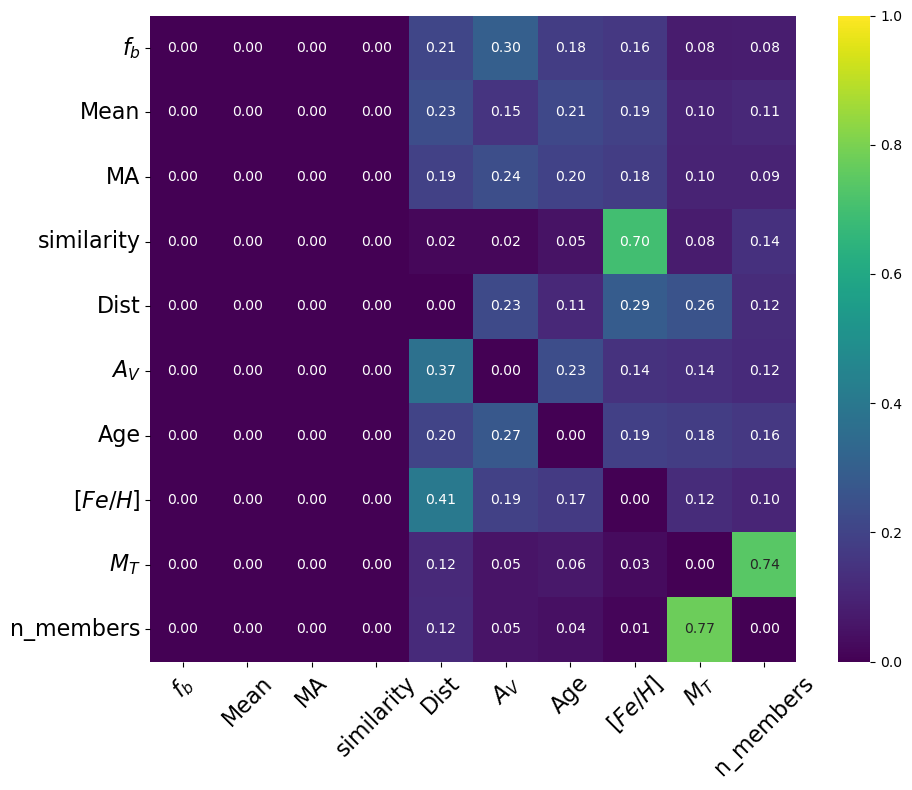

In [52]:
from sklearn.ensemble import RandomForestRegressor


importance_matrix = pd.DataFrame(index=cols, columns=cols, data=0.0)

fbs = ['bin_frac', 'corr_mean', 'corr_MA', 'corr_similarity']
for target in cols:
    features = [c for c in cols if (c != target) & (c not in fbs)]
    
    X = df_corr[features]
    y = df_corr[target]
    
    model = RandomForestRegressor(n_estimators=100, random_state=0)
    model.fit(X, y)
    

    for idx, feature in enumerate(features):
        importance_matrix.loc[target, feature] = model.feature_importances_[idx]

importance_matrix.rename(index=nome_vars, columns=nome_vars, inplace=True)
fig = plt.figure(figsize=(10, 8))
ax = sns.heatmap(importance_matrix, annot=True, cmap=palette, fmt=".2f", square=True, cbar=True, vmin=0, vmax=1)

for label in ax.get_xticklabels():
    label.set_fontsize(16)
    label.set_rotation(45) 

for label in ax.get_yticklabels():
    label.set_fontsize(16)
    label.set_rotation(0) 

plt.tight_layout()
plt.show()

In [73]:
fbs = ['bin_frac', 'corr_mean', 'corr_MA', 'corr_similarity']
fbs_traduzidos = [nome_vars[var] for var in fbs]

for target in fbs_traduzidos:
    if target in importance_matrix.index:
        print(f"{target}:")
        ranking = importance_matrix.loc[target].sort_index()
        ranking = ranking[ranking > 0] 
        for feature, importance in ranking.items():
            print(f"Peso {feature} = {importance:.1%}")
        print("-" * 40)

$f_b$:
Peso $A_V$ = 29.8%
Peso $M_T$ = 7.6%
Peso Age = 17.7%
Peso Dist = 20.9%
Peso [$Fe/H$] = 16.1%
Peso n_members = 7.8%
----------------------------------------
Mean:
Peso $A_V$ = 14.9%
Peso $M_T$ = 9.8%
Peso Age = 21.5%
Peso Dist = 23.4%
Peso [$Fe/H$] = 19.4%
Peso n_members = 11.0%
----------------------------------------
MA:
Peso $A_V$ = 23.5%
Peso $M_T$ = 9.7%
Peso Age = 19.9%
Peso Dist = 19.5%
Peso [$Fe/H$] = 18.0%
Peso n_members = 9.5%
----------------------------------------
similarity:
Peso $A_V$ = 1.9%
Peso $M_T$ = 7.7%
Peso Age = 5.1%
Peso Dist = 1.8%
Peso [$Fe/H$] = 69.8%
Peso n_members = 13.7%
----------------------------------------
